In [6]:
import pandas as pd
import numpy as np
import seaborn as sea
import matplotlib.pyplot as pkt
import os

In [7]:
c=sea.load_dataset('titanic')

In [8]:
c.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [9]:
c.tail()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


In [10]:
c.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [11]:
c.sex

0        male
1      female
2      female
3      female
4        male
        ...  
886      male
887    female
888    female
889      male
890      male
Name: sex, Length: 891, dtype: object

In [12]:
c.age

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888     NaN
889    26.0
890    32.0
Name: age, Length: 891, dtype: float64

In [13]:
c['pclass']

0      3
1      1
2      3
3      1
4      3
      ..
886    2
887    1
888    3
889    1
890    3
Name: pclass, Length: 891, dtype: int64

In [14]:
c['pclass'].value_counts()

pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [15]:
np.mean(c['survived'])

np.float64(0.3838383838383838)

In [16]:
c['pclass']==1

0      False
1       True
2      False
3       True
4      False
       ...  
886    False
887     True
888    False
889     True
890    False
Name: pclass, Length: 891, dtype: bool

In [17]:
print(np.mean(c['survived'][c['pclass']==1])*100)

62.96296296296296


In [18]:
print(np.mean(c['survived'][c['pclass']==2])*100)

47.28260869565217


In [19]:
print(np.mean(c['survived'][c['pclass']==3])*100)

24.236252545824847


In [20]:
c[["pclass","survived"]].groupby(['pclass']).mean()

,survived
pclass,
1,0.629630
2,0.472826
3,0.242363


In [21]:
c.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [22]:
c.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [23]:
print(len(c[c['survived']==1]))

342


In [24]:
print(len(c[c['survived']==0]))

549


In [25]:
c['sex'].value_counts()

sex
male      577
female    314
Name: count, dtype: int64

In [26]:
c['adult_male'].value_counts()

adult_male
True     537
False    354
Name: count, dtype: int64

In [27]:
print(c[c['sex'] == 'male']['survived'].mean() * 100)


18.890814558058924


In [28]:
print(c[c['sex'] == 'female']['survived'].mean() * 100)


74.20382165605095


In [29]:
c['age'].value_counts()


age
24.00    30
22.00    27
18.00    26
28.00    25
30.00    25
         ..
24.50     1
0.67      1
0.42      1
34.50     1
74.00     1
Name: count, Length: 88, dtype: int64

In [30]:
#27/2/26
print(c[c["sex"]=='male'].groupby("pclass")['survived'].sum())


pclass
1    45
2    17
3    47
Name: survived, dtype: int64


In [31]:
print(c[c["sex"]=='female'].groupby("pclass")['survived'].sum())

pclass
1    91
2    70
3    72
Name: survived, dtype: int64


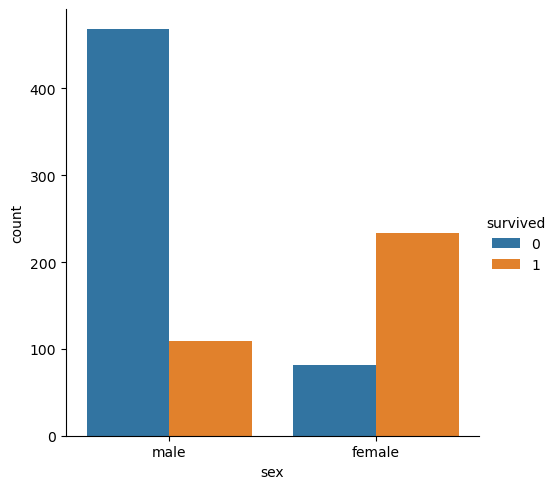

In [32]:

sea.catplot(x = 'sex',hue = 'survived',kind='count',data=c)

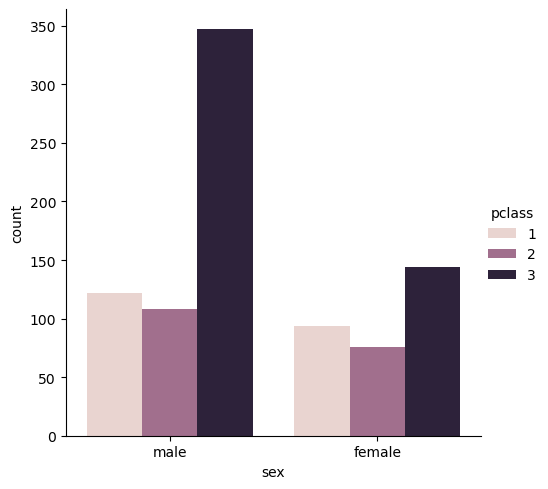

In [33]:

sea.catplot(x = 'sex',hue = 'pclass',kind='count',data=c)


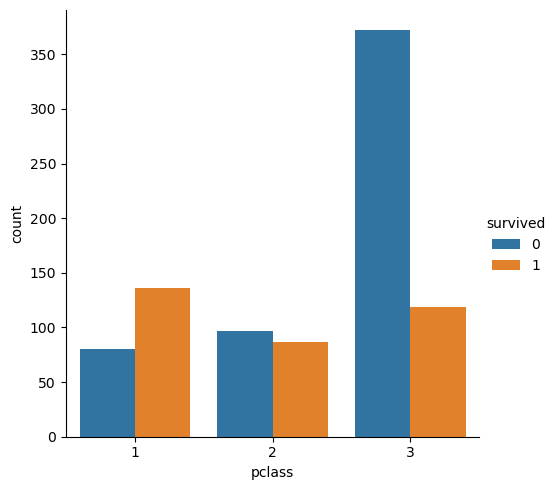

In [34]:
sea.catplot(x = 'pclass',hue = 'survived',kind='count',data=c)

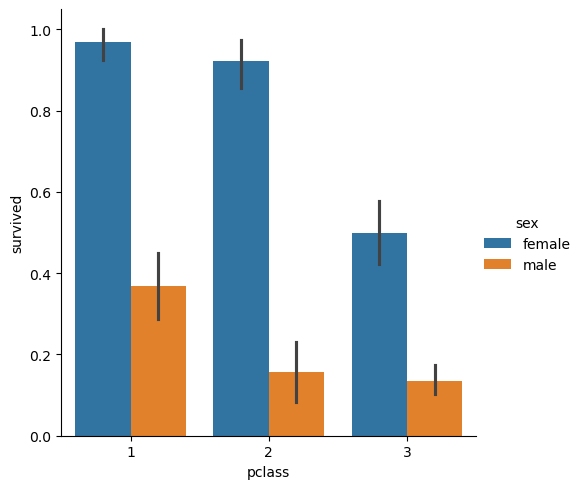

In [35]:
sea.catplot(x = 'pclass',y = 'survived',hue = 'sex', kind='bar',data=c)

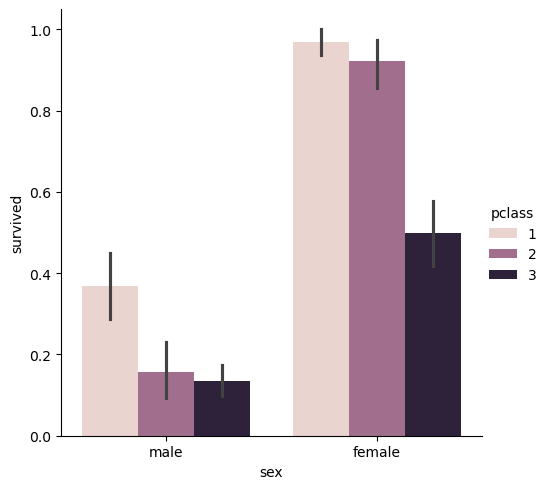

In [36]:
sea.catplot(x = 'sex',y= 'survived',hue = 'pclass' ,kind='bar',data=c)

In [37]:
c[(c["sex"] == 'female' ) & (c["survived"] == 1)].groupby("pclass")["survived"].count()
#233

pclass
1    91
2    70
3    72
Name: survived, dtype: int64

In [38]:
c[(c["sex"] == 'male' ) & (c["survived"] == 1)].groupby("pclass")["survived"].count()
#109

pclass
1    45
2    17
3    47
Name: survived, dtype: int64

In [39]:
c[(c["sex"] == 'female' ) & (c["survived"] == 0)].groupby("pclass")["survived"].count()

pclass
1     3
2     6
3    72
Name: survived, dtype: int64

In [40]:
# death
c[(c["sex"] == 'male' ) & (c["survived"] == 0)].groupby("pclass")["survived"].count()


pclass
1     77
2     91
3    300
Name: survived, dtype: int64

<Axes: >

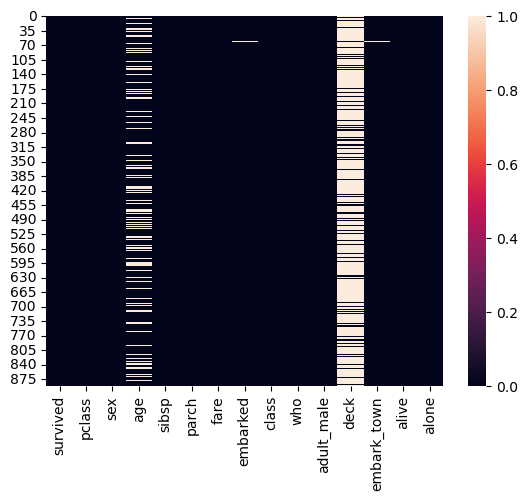

In [41]:
sea.heatmap(c.isnull())

<Axes: >

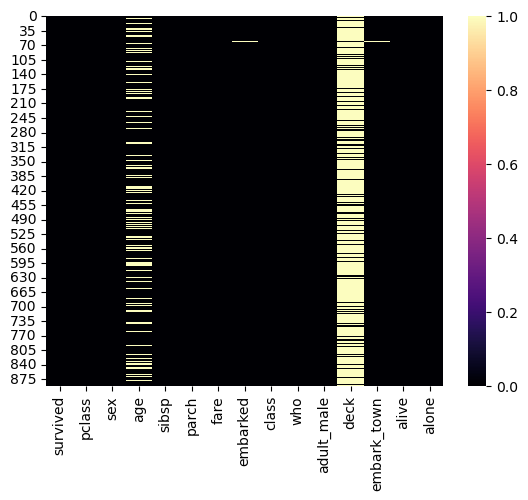

In [42]:
sea.heatmap(c.isnull(),cmap="magma")

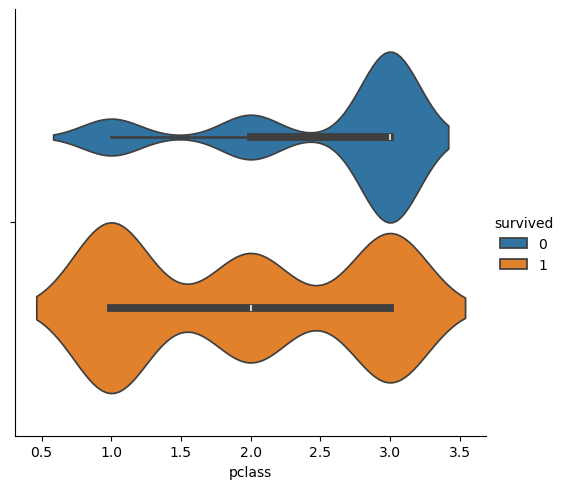

In [46]:
print(sea.catplot(x='pclass',hue='survived',kind='violin',data=c))